# QRT Data Challenge Initial Exploration

## Loading libraries

In [1]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

#Set-up plot 
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully")

Libraries loaded successfully


## Loading data

In [2]:
#Loading data
X_train = pd.read_csv('../data/X_train_9xQjqvZ.csv', index_col = 'ROW_ID')
X_test = pd.read_csv('../data/X_test_1zTtEnD.csv', index_col = 'ROW_ID')
y_train = pd.read_csv('../data/y_train_Ppwhaz8.csv', index_col = 'ROW_ID')

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (527073, 44)
X_test shape: (31870, 44)
y_train shape: (527073, 1)


In [3]:
#Looking at first few rows of X_train
print(f"First 5 rows of X_train: {X_train.head()}")

First 5 rows of X_train:                TS     ALLOCATION    RET_20    RET_19    RET_18    RET_17  \
ROW_ID                                                                     
0       DATE_0001  ALLOCATION_01 -0.018192 -0.000306 -0.006881 -0.002393   
1       DATE_0001  ALLOCATION_02 -0.006394 -0.001059  0.001565  0.000033   
2       DATE_0001  ALLOCATION_03 -0.016587 -0.004517 -0.005306  0.004314   
3       DATE_0001  ALLOCATION_04 -0.005344  0.002790  0.006937 -0.004246   
4       DATE_0001  ALLOCATION_05 -0.010506 -0.005491  0.007752 -0.012299   

          RET_16    RET_15    RET_14    RET_13  ...  SIGNED_VOLUME_8  \
ROW_ID                                          ...                    
0       0.000507 -0.001270 -0.002539  0.002830  ...         0.818730   
1       0.002829  0.001725  0.000875 -0.002160  ...        -1.390336   
2       0.006471 -0.005868 -0.005030 -0.001488  ...         0.961318   
3      -0.005051 -0.000330 -0.000117 -0.005209  ...        -0.483377   
4       0.

## Exploring target variables

In [4]:
#Looking at target variable
print("\nFirst 10 targets: ")
print(y_train.head(10))
print("\nTarget statistics: ")
print(y_train.describe())


First 10 targets: 
          target
ROW_ID          
0       0.009210
1       0.000405
2       0.005967
3      -0.000542
4      -0.002579
5       0.002481
6      -0.000771
7      -0.000499
8       0.004876
9       0.002646

Target statistics: 
              target
count  527073.000000
mean        0.000035
std         0.003106
min        -0.051809
25%        -0.001517
50%         0.000041
75%         0.001600
max         0.051803


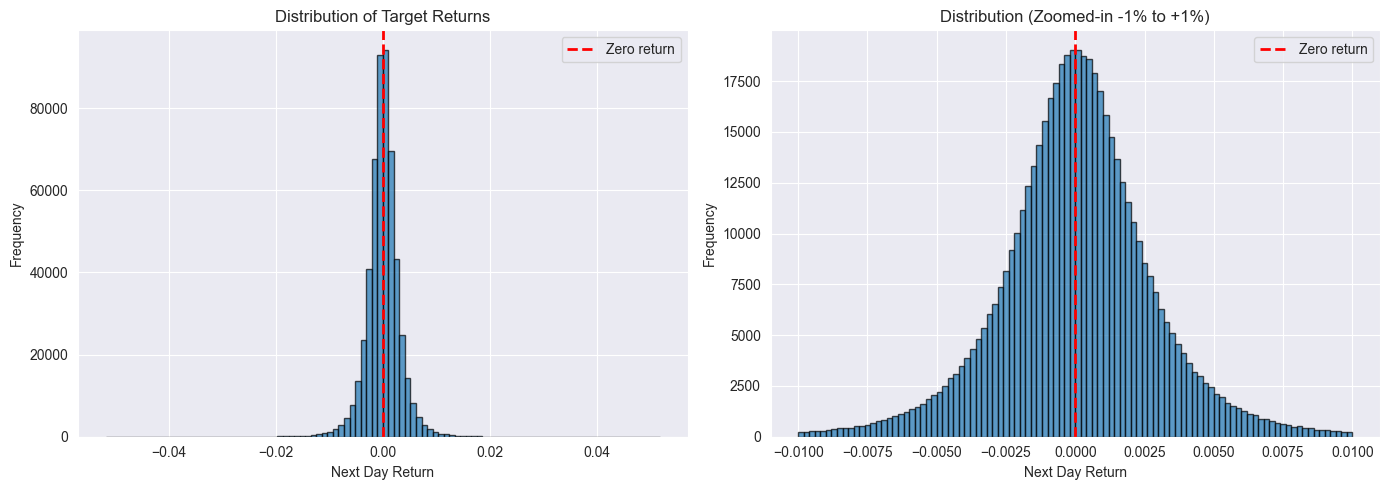


Positive returns: 267,323(50.72%)

Negative returns: 259,750(49.28%)


In [5]:
#Visualising the distribution of returns
plt.figure(figsize = (14, 5))

#Histogram
plt.subplot(1, 2, 1)
plt.hist(y_train['target'], bins = 100, edgecolor = 'black', alpha = 0.7)
plt.axvline(0, color = 'red', linestyle = '--', linewidth = 2, label = 'Zero return')
plt.xlabel('Next Day Return')
plt.ylabel('Frequency')
plt.title('Distribution of Target Returns')
plt.legend()

#Zoomed-in view
plt.subplot(1, 2, 2)
plt.hist(y_train['target'], bins = 100, range = (-0.01, 0.01), edgecolor = 'black', alpha = 0.7)
plt.axvline(0, color = 'red', linestyle = '--', linewidth = 2, label = 'Zero return')
plt.xlabel('Next Day Return')
plt.ylabel('Frequency')
plt.title('Distribution (Zoomed-in -1% to +1%)')
plt.legend()

plt.tight_layout()
plt.show()

#Checking class balances
positive_returns = (y_train['target'] > 0).sum()
negative_returns = (y_train['target'] <= 0).sum()
print(f"\nPositive returns: {positive_returns:,}({positive_returns/len(y_train)*100:.2f}%)")
print(f"\nNegative returns: {negative_returns:,}({negative_returns/len(y_train)*100:.2f}%)")

## Handling missing values

In [6]:
#Checking columns
print("All columns in X_train: ")
print(X_train.columns.tolist())
print(f"\nTotal features: {len(X_train.columns)}")

#Checking for missing values
print("\n\nMissing values: ")
missing = X_train.isnull().sum()
print(missing[missing > 0])

All columns in X_train: 
['TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16', 'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10', 'RET_9', 'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2', 'RET_1', 'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18', 'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15', 'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12', 'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9', 'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6', 'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3', 'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP']

Total features: 44


Missing values: 
RET_20                       58
RET_19                       50
RET_18                       42
RET_17                       34
RET_16                       26
RET_15                       18
RET_14                       13
RET_13                        9
RET_12                        6
RET_11     

In [7]:
#Checking SIGNED_VOLUME_1 values as it has the most missing values
print("Row with missing SIGNED_VOLUME_1: ")
print(X_train[X_train['SIGNED_VOLUME_1'].isna()].head(1))
print("\nRow with SIGNED_VOLUME_1: ")
print(X_train[X_train['SIGNED_VOLUME_1'].notna()].head(1))

Row with missing SIGNED_VOLUME_1: 
               TS     ALLOCATION    RET_20    RET_19    RET_18    RET_17  \
ROW_ID                                                                     
0       DATE_0001  ALLOCATION_01 -0.018192 -0.000306 -0.006881 -0.002393   

          RET_16   RET_15    RET_14   RET_13  ...  SIGNED_VOLUME_8  \
ROW_ID                                        ...                    
0       0.000507 -0.00127 -0.002539  0.00283  ...          0.81873   

        SIGNED_VOLUME_7  SIGNED_VOLUME_6  SIGNED_VOLUME_5  SIGNED_VOLUME_4  \
ROW_ID                                                                       
0              0.941014         0.714129        -0.323847         0.525097   

        SIGNED_VOLUME_3  SIGNED_VOLUME_2  SIGNED_VOLUME_1  \
ROW_ID                                                      
0              0.363601        -0.219328              NaN   

        MEDIAN_DAILY_TURNOVER  GROUP  
ROW_ID                                
0                    0.09690

In [8]:
#Check the pattern of missing values 
missing_pct = (X_train.isnull().sum() / len(X_train) * 100).sort_values(ascending=False)
print("Percentage of missing values:\n")
print(missing_pct[missing_pct > 0])

# Checking if the same rows are missing across multiple SIGNED_VOLUME columns
print("\n\nChecking if missing values overlap:")
sv1_missing = X_train['SIGNED_VOLUME_1'].isna()
sv2_missing = X_train['SIGNED_VOLUME_2'].isna()
sv20_missing = X_train['SIGNED_VOLUME_20'].isna()

print(f"Rows missing SV_1: {sv1_missing.sum():,}")
print(f"Rows missing SV_2: {sv2_missing.sum():,}")
print(f"Rows missing SV_20: {sv20_missing.sum():,}")
print(f"Rows missing BOTH SV_1 AND SV_2: {(sv1_missing & sv2_missing).sum():,}")

Percentage of missing values:

SIGNED_VOLUME_1          73.520366
SIGNED_VOLUME_20          1.612300
MEDIAN_DAILY_TURNOVER     0.690227
SIGNED_VOLUME_19          0.569561
SIGNED_VOLUME_18          0.162976
RET_20                    0.011004
SIGNED_VOLUME_17          0.011004
SIGNED_VOLUME_16          0.009486
RET_19                    0.009486
RET_18                    0.007969
SIGNED_VOLUME_15          0.007969
RET_17                    0.006451
SIGNED_VOLUME_14          0.006451
RET_16                    0.004933
SIGNED_VOLUME_13          0.004933
RET_15                    0.003415
SIGNED_VOLUME_12          0.003415
SIGNED_VOLUME_11          0.002466
RET_14                    0.002466
SIGNED_VOLUME_10          0.001708
RET_13                    0.001708
SIGNED_VOLUME_9           0.001138
RET_12                    0.001138
SIGNED_VOLUME_8           0.000759
RET_11                    0.000759
SIGNED_VOLUME_7           0.000379
RET_10                    0.000379
dtype: float64


Checkin

In [9]:
#Drop column SIGNED_VOLUME_1 since 73% is missing (for the most recent day)
X_train_clean = X_train.drop('SIGNED_VOLUME_1', axis = 1)
X_test_clean = X_test.drop('SIGNED_VOLUME_1', axis = 1)

#Fill remaining values with 0 (good option for now since missing values are <2%)
X_train_clean = X_train_clean.fillna(0)
X_test_clean = X_test_clean.fillna(0)

print(f"Cleaned X_train shape: {X_train_clean.shape}")
print(f"Remaining missing values check: {X_train_clean.isnull().sum().sum()}")

Cleaned X_train shape: (527073, 43)
Remaining missing values check: 0


## Preparing features

In [10]:
#Preparing features
#Dropping non-numeric colummns
feature_columns = [col for col in X_test_clean.columns if col not in ['TS', 'ALLOCATION']]

X = X_train_clean[feature_columns]
y = (y_train['target'] > 0).astype(int) #Convert to nonary: 1 if positive and 0 is negative

print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {feature_columns[:10]}")#print first 10
print(f"\nTarget distibution: ")
print(y.value_counts())

Feature shape: (527073, 41)
Target shape: (527073,)
Feature columns: ['RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16', 'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11']

Target distibution: 
target
1    267323
0    259750
Name: count, dtype: int64


## Training models

In [11]:
#Training data
#Importing libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#Splitting data into train and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f"Training set: {X_train_split.shape[0]:,} rows")
print(f"Validation set: {X_val_split.shape[0]:,} rows")


Training set: 421,658 rows
Validation set: 105,415 rows


In [12]:
#Training a simple Logistic Regression model
lr_model = LogisticRegression(max_iter = 1000, random_state = 42)
lr_model.fit(X_train_split, y_train_split)

#Make predictions
y_pred_lr = lr_model.predict(X_val_split)

#Calculate accuracy
lr_accuracy = accuracy_score(y_val_split, y_pred_lr)

print(f"Logistic Regression accuracy: {lr_accuracy: .4f} ({lr_accuracy*100:.2f}%)")

Logistic Regression accuracy:  0.5097 (50.97%)


In [13]:
#Trying benchmark's Lightgbm 
import lightgbm as lgb

#Training LightGBM
lgb_model = lgb.LGBMClassifier(
    objective = 'binary',
    metric = 'binary_logloss',
    n_estimators = 100,
    learning_rate = 0.05,
    random_state = 42,
    verbose = -1
)

lgb_model.fit(X_train_split, y_train_split)

#Make predictions
y_pred_lgb = lgb_model.predict(X_val_split)

#Calculate accuracy
lgb_accuracy = accuracy_score(y_val_split, y_pred_lgb)

print(f"LightGBM accuracy: {lgb_accuracy: .4f} ({lgb_accuracy*100:.2f}%)")

LightGBM accuracy:  0.5388 (53.88%)


In [14]:
from sklearn.model_selection import KFold

# 5-Fold Cross-Validation like the benchmark
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print("Running 5-Fold Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    # Split data
    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]
    
    # Train model
    lgb_model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=100,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    )
    lgb_model.fit(X_train_fold, y_train_fold)
    
    # Predict and score
    y_pred = lgb_model.predict(X_val_fold)
    accuracy = accuracy_score(y_val_fold, y_pred)
    cv_scores.append(accuracy)
    
    print(f"Fold {fold}: {accuracy:.4f}")

print(f"\n{'='*40}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"Std Dev: {np.std(cv_scores):.4f}")
print(f"Benchmark: 0.5079")

Running 5-Fold Cross-Validation...
Fold 1: 0.5383
Fold 2: 0.5332
Fold 3: 0.5354
Fold 4: 0.5369
Fold 5: 0.5358

Mean CV Accuracy: 0.5359
Std Dev: 0.0017
Benchmark: 0.5079


## Final model and submission file creation

In [15]:
# Train on ALL training data (no split)
print("Training final model on all training data...")
final_model = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)
final_model.fit(X, y)

# Prepare test data
X_test_features = X_test_clean[feature_columns]

# Predict on test set
test_predictions = final_model.predict(X_test_features)

# Create submission file
submission = pd.DataFrame({
    'ROW_ID': X_test_clean.index,
    'prediction': test_predictions
})

submission.to_csv('../data/firstExp_submission.csv', index=False)
print("Submission file created!")
print(f"\nFirst 10 predictions:")
print(submission.head(10))

Training final model on all training data...
Submission file created!

First 10 predictions:
   ROW_ID  prediction
0  527073           0
1  527074           1
2  527075           1
3  527076           0
4  527077           0
5  527078           1
6  527079           1
7  527080           0
8  527081           1
9  527082           0
